# **Import Library**

In [14]:
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# **DataLoad**

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
#pd.read_csv('/content/Symptom2Disease.csv')
import csv
data = pd.read_csv('/content/drive/MyDrive/Symptom2Disease.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
disease_counts = data['label'].value_counts()
print(disease_counts)

label
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Dengue                             50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                               50
Bronchial Asthma                   50
Hypertension                       50
Migraine                           50
Cervical spondylosis               50
Jaundice                           50
Malaria                            50
urinary tract infection            50
allergy                            50
gastroesophageal reflux disease    50
drug reaction                      50
peptic ulcer disease               50
diabetes                           50
Name: count, dtype: int64



# Data Preprocessing

In [17]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Case folding (convert text to lowercase)
def case_folding(text_series):
    return text_series.str.lower()

data_revised = data.copy()  # Create a copy of the original data for revisions
data_revised['text'] = case_folding(data_revised['text'])  # Assuming the column to clean is 'text'

# Step 2: Remove punctuation
punctuations = "!()-[]{};:'\"\\,<>./?@#$%^&*_~"

def remove_punctuation(text):
    return ''.join([char for char in text if char not in punctuations])

data_revised['text'] = data_revised['text'].apply(remove_punctuation)

# Step 3: Remove stopwords
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
custom_stopwords = {'ive', 'lot', 'im'}
stop_words = stop_words.union(custom_stopwords)

data_revised['text'] = data_revised['text'].apply(lambda sentence: ' '.join(
    [word for word in nltk.word_tokenize(sentence) if word.lower() not in stop_words]
))

# Step 4: Tokenization (convert sentence to a list of words)
data_revised['text'] = data_revised['text'].apply(nltk.word_tokenize)

# Step 5: Lemmatization (reduce words to their base form)
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

data_revised['text'] = data_revised['text'].apply(lambda sentence: ' '.join(
    [lemmatizer.lemmatize(word) for word in sentence]
))

# Step 6: Apply TF-IDF
tfidf_vectorizer = TfidfVectorizer()
data_tfidf = tfidf_vectorizer.fit_transform(data_revised['text'])

# Output the TF-IDF transformed data (as sparse matrix)
print(data_tfidf)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17462 stored elements and shape (1200, 1371)>
  Coords	Values
  (0, 419)	0.16222031904004106
  (0, 1065)	0.14643512882484233
  (0, 937)	0.16827764705187032
  (0, 73)	0.22194960590767734
  (0, 679)	0.2195975751886655
  (0, 1227)	0.3915553711183681
  (0, 857)	0.2975627979775866
  (0, 1329)	0.3183929247545449
  (0, 956)	0.1954080059096226
  (0, 652)	0.22695846285382387
  (0, 261)	0.30705404473495823
  (0, 363)	0.23743212898507812
  (0, 1003)	0.40835625422626043
  (0, 858)	0.2758631632885976
  (1, 1065)	0.1277461782960467
  (1, 863)	0.571222478444561
  (1, 395)	0.2325518807737005
  (1, 661)	0.2856112392222805
  (1, 374)	0.2815332720455337
  (1, 1002)	0.306268628886372
  (1, 832)	0.20622783511588277
  (1, 9)	0.22963980867757766
  (1, 166)	0.2482174241988215
  (1, 1120)	0.35623932098350314
  (1, 1022)	0.2547302010433578
  :	:
  (1198, 621)	0.421044722682301
  (1198, 1240)	0.16030737107752346
  (1198, 153)	0.16145563802166402
  (11

# **Data Training Test Split**

In [18]:
from sklearn.model_selection import train_test_split

# X should be your TF-IDF matrix (features), and y should be your labels (target)
X = data_tfidf  # TF-IDF matrix (already preprocessed)
y = data['label']  # Assuming your original dataset has a 'label' column

# Split the data into training and testing sets (stratified by label for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Check the sizes of the split datasets
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Check label distribution in the training and testing sets
train_label_counts = y_train.value_counts()
print(f"\nLabel distribution in the training set:\n{train_label_counts}")

test_label_counts = y_test.value_counts()
print(f"\nLabel distribution in the testing set:\n{test_label_counts}")


Training set size: 960
Testing set size: 240

Label distribution in the training set:
label
Chicken pox                        40
Common Cold                        40
Dimorphic Hemorrhoids              40
drug reaction                      40
Dengue                             40
Pneumonia                          40
Arthritis                          40
Hypertension                       40
allergy                            40
Acne                               40
gastroesophageal reflux disease    40
urinary tract infection            40
Impetigo                           40
peptic ulcer disease               40
Cervical spondylosis               40
diabetes                           40
Bronchial Asthma                   40
Varicose Veins                     40
Fungal infection                   40
Jaundice                           40
Typhoid                            40
Psoriasis                          40
Migraine                           40
Malaria                           

# **Machine learning model**

**Logistic Regression**

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print(classification_report(y_test, y_pred))



Accuracy: 0.95
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.90      0.90      0.90        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria    

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Step 4: Evaluate the Random Forest model performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

# Step 5: Print a detailed classification report for Random Forest predictions
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.94
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.70      0.70      0.70        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      0.90      0.95        10
                       Jaundice       1.00      1.00      1.00        10
                     

# **Decision Tree**

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")

print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.80
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.90      0.90      0.90        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.56      0.50      0.53        10
                    Common Cold       0.75      0.90      0.82        10
                         Dengue       0.56      0.50      0.53        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.64      0.90      0.75        10
                   Hypertension       0.90      0.90      0.90        10
                       Impetigo       1.00      0.60      0.75        10
                       Jaundice       0.91      1.00      0.95        10
                     

# **SVM(Support Vector Machine)**

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = SVC(kernel='linear', random_state=42)  # You can choose different kernels, e.g., 'linear', 'rbf'
svm_model.fit(X_train, y_train)  # Train the model on TF-IDF transformed training data

# Step 3: Make predictions on the test data using the trained SVM model
y_pred_svm = svm_model.predict(X_test)

# Step 4: Evaluate the SVM model performance
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.2f}")

# Step 5: Print a detailed classification report for SVM predictions
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.95
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.82      0.90      0.86        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria

# **KNN**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Step 3: Make predictions on the test data using the trained KNN model
y_pred_knn = knn_model.predict(X_test)

# Step 4: Evaluate the KNN model performance
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.2f}")

# Step 5: Print a detailed classification report for KNN predictions
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.93
                                 precision    recall  f1-score   support

                           Acne       0.91      1.00      0.95        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.69      0.90      0.78        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.86      0.60      0.71        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       0.91      1.00      0.95        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria

In [24]:
# Step 1: Define the preprocess_text function
def preprocess_text(text):
    # Example preprocessing (adjust this based on your training preprocessing)
    text = text.lower()  # Convert to lowercase
    tokens = word_tokenize(text)  # Tokenize the text
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]  # Lemmatize tokens
    return ' '.join(tokens)  # Return preprocessed tex

KNN Accuracy: 0.93
                                 precision    recall  f1-score   support

                           Acne       0.91      1.00      0.95        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.69      0.90      0.78        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.86      0.60      0.71        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       0.91      1.00      0.95        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria

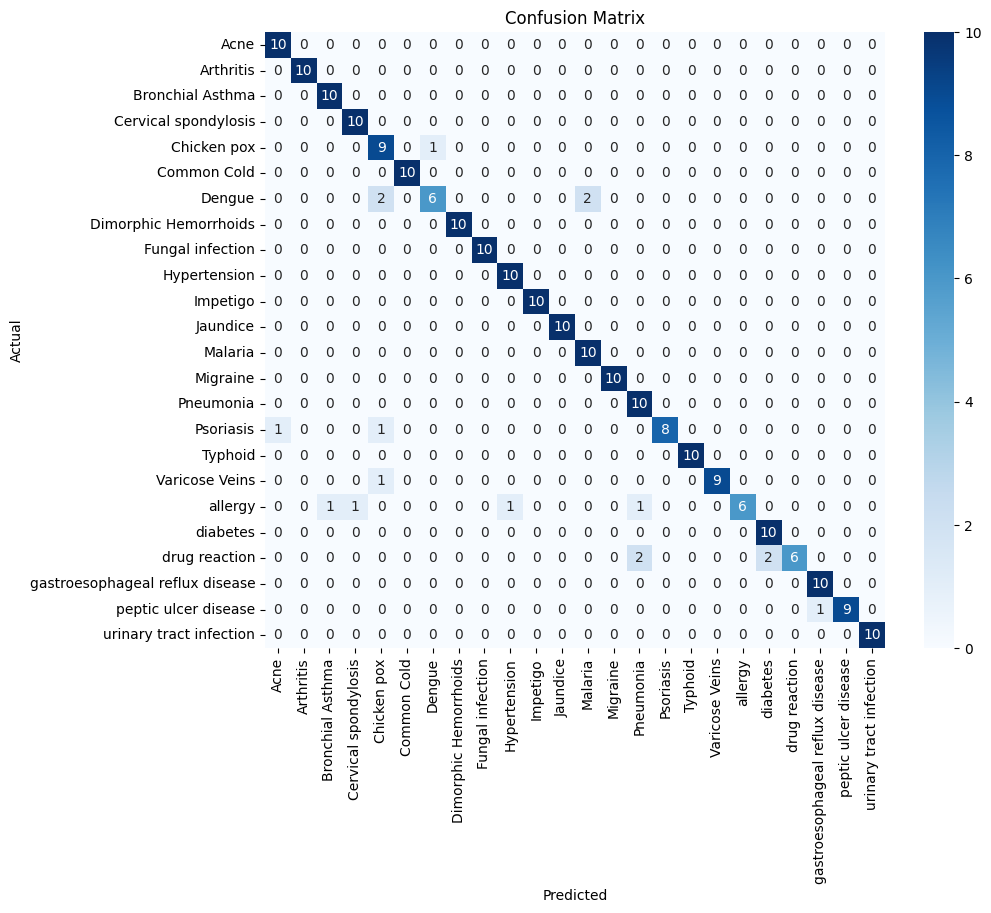

In [25]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer



# Step 3: Make predictions on the test data
y_pred_knn = knn_model.predict(X_test)

# Step 4: Evaluate the KNN model performance
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.2f}")

# Print a detailed classification report
print(classification_report(y_test, y_pred_knn))

# Step 5: Create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_knn)

# Step 6: Extract unique class labels from y_train (or you can use y_test)
class_labels = np.unique(y_train)

# Step 7: Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




In [28]:

def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in punctuations])
    tokens = word_tokenize(text)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return ' '.join(tokens)

print("=" * 60)
print("🏥  DISEASE PREDICTION SYSTEM")
print("=" * 60)
print("Describe your symptoms in English (e.g. 'I have fever, headache, and chills')")
print()

symptom = input("📝 Enter your symptoms: ")

preprocessed = preprocess_text(symptom)
symptom_tfidf = tfidf_vectorizer.transform([preprocessed])

print()
print("=" * 60)
print("🔍  PREDICTIONS FROM ALL MODELS")
print("=" * 60)

# Logistic Regression
lr_pred = model.predict(symptom_tfidf)[0]
lr_prob = max(model.predict_proba(symptom_tfidf)[0]) * 100
print(f"📌 Logistic Regression  : {lr_pred:<35} (confidence: {lr_prob:.1f}%)")

# Random Forest
rf_pred = rf_model.predict(symptom_tfidf)[0]
rf_prob = max(rf_model.predict_proba(symptom_tfidf)[0]) * 100
print(f"🌲 Random Forest        : {rf_pred:<35} (confidence: {rf_prob:.1f}%)")

# Decision Tree
dt_pred = dt_model.predict(symptom_tfidf)[0]
print(f"🌿 Decision Tree        : {dt_pred:<35}")

# SVM
svm_pred = svm_model.predict(symptom_tfidf)[0]
print(f"⚙️  SVM                  : {svm_pred:<35}")

# KNN
knn_pred = knn_model.predict(symptom_tfidf)[0]
knn_prob = max(knn_model.predict_proba(symptom_tfidf)[0]) * 100
print(f"👥 KNN                  : {knn_pred:<35} (confidence: {knn_prob:.1f}%)")

print()
print("=" * 60)

# Majority vote
from collections import Counter
all_preds = [lr_pred, rf_pred, dt_pred, svm_pred, knn_pred]
majority = Counter(all_preds).most_common(1)[0][0]
votes = Counter(all_preds).most_common(1)[0][1]

print(f"🏆  FINAL VERDICT (majority vote): {majority}")
print(f"    Agreed by {votes}/5 models")
print("=" * 60)

🏥  DISEASE PREDICTION SYSTEM
Describe your symptoms in English (e.g. 'I have fever, headache, and chills')

📝 Enter your symptoms: im heart break, nausea fever sad and empty

🔍  PREDICTIONS FROM ALL MODELS
📌 Logistic Regression  : Pneumonia                           (confidence: 11.4%)
🌲 Random Forest        : Pneumonia                           (confidence: 30.0%)
🌿 Decision Tree        : Pneumonia                          
⚙️  SVM                  : drug reaction                      
👥 KNN                  : urinary tract infection             (confidence: 60.0%)

🏆  FINAL VERDICT (majority vote): Pneumonia
    Agreed by 3/5 models
